In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
Columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
            'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
            'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count',
            'serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
            'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
            'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate',
            'dst_host_srv_rerror_rate','attack','level'])

In [4]:
data = pd.read_csv("nsl-kdd/KDDTrain+.txt" , sep = "," , encoding = 'utf-8')

In [5]:
# load data
data.columns = Columns

In [6]:
null_counts = data.isnull().sum()
# Print the number of null values
print(f"{null_counts.sum()} null entries have been found in the dataset\n")
# Drop null values
data.dropna(inplace=True)          # or df_data = df_data.dropna()

# Find and handle duplicates
duplicate_count = data.duplicated().sum()
# Print the number of duplicate entries
print(f"{duplicate_count} duplicate entries have been found in the dataset\n")
# Remove duplicates
data.drop_duplicates(inplace=True)  # or df_data = df_data.drop_duplicates()
# Display relative message
print(f"All duplicates have been removed\n")

# Reset the indexes
data.reset_index(drop=True, inplace=True)

# Inspect the dataset for categorical columns
print("Categorical columns:",data.select_dtypes(include=['object']).columns.tolist(),'\n')

# Print the first 5 lines
data.head()

0 null entries have been found in the dataset

0 duplicate entries have been found in the dataset

All duplicates have been removed

Categorical columns: ['protocol_type', 'service', 'flag', 'attack'] 



,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [7]:
# number of attack labels 
data['attack'].value_counts()

normal             67342
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: attack, dtype: int64

In [8]:
# changing attack labels to their respective attack class
def change_label(df):
  df.attack.replace(['back','land','neptune','pod','smurf','teardrop'],'Dos',inplace=True)
  df.attack.replace(['guess_passwd','imap','ftp_write','multihop','phf','spy','warezclient','warezmaster'],'R2L',inplace=True)      
  df.attack.replace(['ipsweep','nmap','portsweep','satan'],'Probe',inplace=True)
  df.attack.replace(['buffer_overflow','loadmodule','perl','rootkit'],'U2R',inplace=True)

In [9]:
change_label(data)

In [10]:
# distribution of attack classes
data.attack.value_counts()

normal    67342
Dos       45927
Probe     11656
R2L         995
U2R          52
Name: attack, dtype: int64

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125972 non-null  int64  
 1   protocol_type                125972 non-null  object 
 2   service                      125972 non-null  object 
 3   flag                         125972 non-null  object 
 4   src_bytes                    125972 non-null  int64  
 5   dst_bytes                    125972 non-null  int64  
 6   land                         125972 non-null  int64  
 7   wrong_fragment               125972 non-null  int64  
 8   urgent                       125972 non-null  int64  
 9   hot                          125972 non-null  int64  
 10  num_failed_logins            125972 non-null  int64  
 11  logged_in                    125972 non-null  int64  
 12  num_compromised              125972 non-null  int64  
 13 

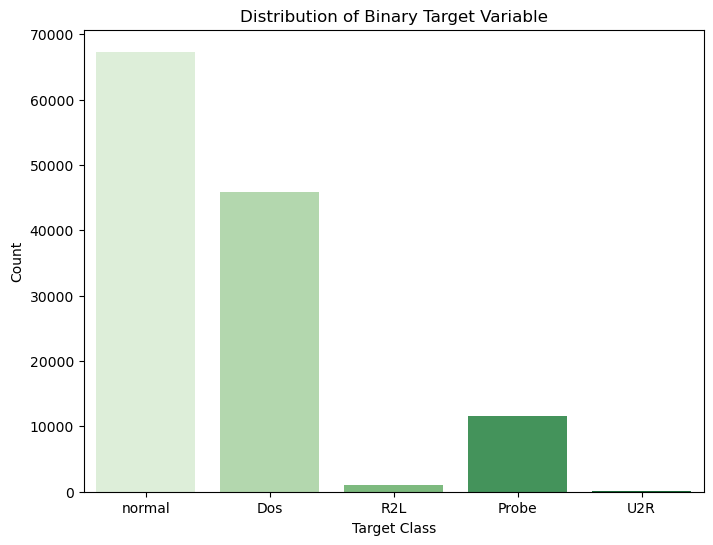

In [12]:
# Plotting the distribution of the binary target variable y
plt.figure(figsize=(8, 6))
sns.countplot(x=data['attack'], palette='Greens')
plt.title('Distribution of Binary Target Variable')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

In [12]:
# Import label encoder
from sklearn import preprocessing

# label_encoder object knows
# how to understand word labels.
label_encoder = preprocessing.LabelEncoder()

# Encode labels in column 'species'.
data['attack']= label_encoder.fit_transform(data['attack'])
data['protocol_type']= label_encoder.fit_transform(data['protocol_type'])
data['service']= label_encoder.fit_transform(data['service'])
data['flag']= label_encoder.fit_transform(data['flag'])

In [13]:
del data['level']

In [16]:
X = data.drop(["attack"],axis =1)
y = data["attack"]

# FS

# PCA

In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [18]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data (important for PCA)
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# Apply PCA
pca = PCA()
X_train_pca = pca.fit_transform(X_train_std)

# Calculate the cumulative explained variance
cumulative_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

# Determine the number of components to keep for 85% variance explained
n_components = np.argmax(cumulative_variance_ratio >= 0.85) + 1

# Apply PCA with the selected number of components
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

In [16]:
from sklearn.metrics import accuracy_score # for calculating accuracy of model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

In [56]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []
auc = []
fpr = []
fnr = []

#function to call for storing the results
def storeResults(model, a,b,c,d,e,f,g):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))
    auc.append(round(e, 3))
    fpr.append(round(f, 3))
    fnr.append(round(g, 3))

# SVM

In [53]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
from sklearn import svm
svc = svm.SVC()
param_dist = {
    'C': uniform(0.1, 10),  # Uniform distribution between 0.1 and 10
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'] + list(np.logspace(-3, 3, 50))
}

# Create the RandomizedSearchCV object
randomized_search = RandomizedSearchCV(estimator=svc, param_distributions=param_dist, n_iter=20, cv=5)

randomized_search.fit(X_train_pca, y_train)

RandomizedSearchCV(cv=5,
                   estimator=SVC(decision_function_shape='ovo',
                                 probability=True),
                   n_iter=20,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000022F2948B9A0>,
                                        'gamma': ['scale', 'auto', 0.001,
                                                  0.0013257113655901094,
                                                  0.0017575106248547913,
                                                  0.002329951810515372,
                                                  0.0030888435964774815,
                                                  0.004094915062380427,
                                                  0.005428...
                                                  0.022229964825261943,
                                                  0.029470517025518096,
                                                  0.03

In [55]:
# Get the best hyperparameters and model
best_params_rand = randomized_search.best_params_
best_model_rand = randomized_search.best_estimator_

# Evaluate the best model
y_pred_best_rand = best_model_rand.predict(X_test_pca)
accuracy_best_rand = accuracy_score(y_test, y_pred_best_rand)
print(f"Best SVM Accuracy: {accuracy_best_rand:.2f}")
print(f"Best Hyperparameters: {best_params_rand}")

Best SVM Accuracy: 0.97
Best Hyperparameters: {'C': 9.413008224364583, 'gamma': 0.49417133613238334, 'kernel': 'rbf'}


In [59]:
from sklearn import svm
svc = svm.SVC(C=9.413008224364583, gamma=0.49417133613238334, kernel='rbf',probability=True)
svc.fit(X_train_pca, y_train)

y_pred    = svc.predict(X_test_pca)

svc_acc = accuracy_score(y_pred, y_test)
svc_prec = precision_score(y_pred, y_test,average='weighted')
svc_rec = recall_score(y_pred, y_test,average='weighted')
svc_f1 = f1_score(y_pred, y_test,average='weighted')
svc_auc = roc_auc_score(y_test, svc.predict_proba(X_test_pca), multi_class='ovr')
tpr = recall_score(y_pred, y_test,average='weighted')
tnr = recall_score(y_pred, y_test,average='weighted', pos_label = 0) 
svc_fpr = 1 - tnr
svc_fnr = 1 - tpr

In [60]:
storeResults('SVM',svc_acc,svc_prec,svc_rec,svc_f1,svc_auc,svc_fpr,svc_fnr)

# Naive Bayes

In [61]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

params_NB = {'var_smoothing': np.logspace(0,-9, num=100)}
# Create the RandomizedSearchCV object
randomized_search = RandomizedSearchCV(estimator=nb, param_distributions=params_NB, n_iter=20, cv=5)

randomized_search.fit(X_train_pca, y_train)

RandomizedSearchCV(cv=5, estimator=GaussianNB(), n_iter=20,
                   param_distributions={'var_smoothing': array([1.00000000e+00, 8.11130831e-01, 6.57933225e-01, 5.33669923e-01,
       4.32876128e-01, 3.51119173e-01, 2.84803587e-01, 2.31012970e-01,
       1.87381742e-01, 1.51991108e-01, 1.23284674e-01, 1.00000000e-01,
       8.11130831e-02, 6.57933225e-02, 5.33669923e-02, 4.32876128e-02,
       3.5111917...
       1.23284674e-07, 1.00000000e-07, 8.11130831e-08, 6.57933225e-08,
       5.33669923e-08, 4.32876128e-08, 3.51119173e-08, 2.84803587e-08,
       2.31012970e-08, 1.87381742e-08, 1.51991108e-08, 1.23284674e-08,
       1.00000000e-08, 8.11130831e-09, 6.57933225e-09, 5.33669923e-09,
       4.32876128e-09, 3.51119173e-09, 2.84803587e-09, 2.31012970e-09,
       1.87381742e-09, 1.51991108e-09, 1.23284674e-09, 1.00000000e-09])})

In [62]:
# Get the best hyperparameters and model
best_params_rand = randomized_search.best_params_
best_model_rand = randomized_search.best_estimator_

# Evaluate the best model
y_pred_best_rand = best_model_rand.predict(X_test_pca)
accuracy_best_rand = accuracy_score(y_test, y_pred_best_rand)
print(f"Best NB Accuracy: {accuracy_best_rand:.2f}")
print(f"Best Hyperparameters: {best_params_rand}")

Best NB Accuracy: 0.81
Best Hyperparameters: {'var_smoothing': 0.006579332246575682}


In [63]:
nb = GaussianNB(var_smoothing = 0.006579332246575682)
nb.fit(X_train_pca, y_train)

y_pred    = nb.predict(X_test_pca)

nb_acc = accuracy_score(y_pred, y_test)
nb_prec = precision_score(y_pred, y_test,average='weighted')
nb_rec = recall_score(y_pred, y_test,average='weighted')
nb_f1 = f1_score(y_pred, y_test,average='weighted')
nb_auc = roc_auc_score(y_test, nb.predict_proba(X_test_pca), multi_class='ovr')
tpr = recall_score(y_pred, y_test,average='weighted')
tnr = recall_score(y_pred, y_test,average='weighted', pos_label = 0) 
nb_fpr = 1 - tnr
nb_fnr = 1 - tpr

In [64]:
storeResults('Naive Bayes',nb_acc,nb_prec,nb_rec,nb_f1,nb_auc,nb_fpr,nb_fnr)

# DecisionTree

In [65]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5,min_samples_split=2)
dt.fit(X_train_pca, y_train)

y_pred    = dt.predict(X_test_pca)

dt_acc = accuracy_score(y_pred, y_test)
dt_prec = precision_score(y_pred, y_test,average='weighted')
dt_rec = recall_score(y_pred, y_test,average='weighted')
dt_f1 = f1_score(y_pred, y_test,average='weighted')
dt_auc = roc_auc_score(y_test, dt.predict_proba(X_test_pca), multi_class='ovr')
tpr = recall_score(y_pred, y_test,average='weighted')
tnr = recall_score(y_pred, y_test,average='weighted', pos_label = 0) 
dt_fpr = 1 - tnr
dt_fnr = 1 - tpr

In [66]:
storeResults('DecisionTree',dt_acc,dt_prec,dt_rec,dt_f1,dt_auc,dt_fpr,dt_fnr)

# Random Forest

In [67]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(max_depth=4,n_estimators=200,min_samples_split=2)
rf.fit(X_train_pca, y_train)

y_pred    = rf.predict(X_test_pca)

rf_acc = accuracy_score(y_pred, y_test)
rf_prec = precision_score(y_pred, y_test,average='weighted')
rf_rec = recall_score(y_pred, y_test,average='weighted')
rf_f1 = f1_score(y_pred, y_test,average='weighted')
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test_pca), multi_class='ovr')
tpr = recall_score(y_pred, y_test,average='weighted')
tnr = recall_score(y_pred, y_test,average='weighted', pos_label = 0) 
rf_fpr = 1 - tnr
rf_fnr = 1 - tpr

In [68]:
storeResults('RandomForest',rf_acc,rf_prec,rf_rec,rf_f1,rf_auc,rf_fpr,rf_fnr)

# Voting Classifier

In [70]:
from sklearn.ensemble import VotingClassifier, BaggingClassifier, AdaBoostClassifier

brf = BaggingClassifier(RandomForestClassifier())
bdt = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), algorithm="SAMME", n_estimators=200
)

model = VotingClassifier(estimators= [('BagRF', brf),('BoostDT', bdt)], voting='soft')

model.fit(X_train_pca, y_train)

y_pred    = model.predict(X_test_pca)

ext_acc = accuracy_score(y_pred, y_test)
ext_prec = precision_score(y_pred, y_test,average='weighted')
ext_rec = recall_score(y_pred, y_test,average='weighted')
ext_f1 = f1_score(y_pred, y_test,average='weighted')
ext_auc = roc_auc_score(y_test, rf.predict_proba(X_test_pca), multi_class='ovr')
tpr = recall_score(y_pred, y_test,average='weighted')
tnr = recall_score(y_pred, y_test,average='weighted', pos_label = 0) 
ext_fpr = 1 - tnr
ext_fnr = 1 - tpr

In [71]:
storeResults('Extension',ext_acc,ext_prec,ext_rec,ext_f1,ext_auc,ext_fpr,ext_fnr)

# Comparison

In [72]:
#creating dataframe
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                       'Precision': precision,
                       'Recall'   : recall, 
                       'F1_score' : f1score,
                       'AUC'  : auc,
                       'FPR' : fpr,
                       'FNR' : fnr
                      }) 

In [73]:
result

,ML Model,Accuracy,Precision,Recall,F1_score,AUC,FPR,FNR
0,SVM,0.969,0.973,0.969,0.971,0.992,0.031,0.031
1,Naive Bayes,0.810,0.869,0.810,0.824,0.953,0.190,0.190
2,DecisionTree,0.926,0.933,0.926,0.928,0.952,0.074,0.074
3,RandomForest,0.928,0.944,0.928,0.936,0.989,0.072,0.072
4,Extension,0.986,0.987,0.986,0.987,0.989,0.014,0.014


# Modelling

In [74]:
import joblib
filename = 'model_pca_nsl.sav'
joblib.dump(model, filename)

['model_pca_nsl.sav']

# Graph

In [76]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

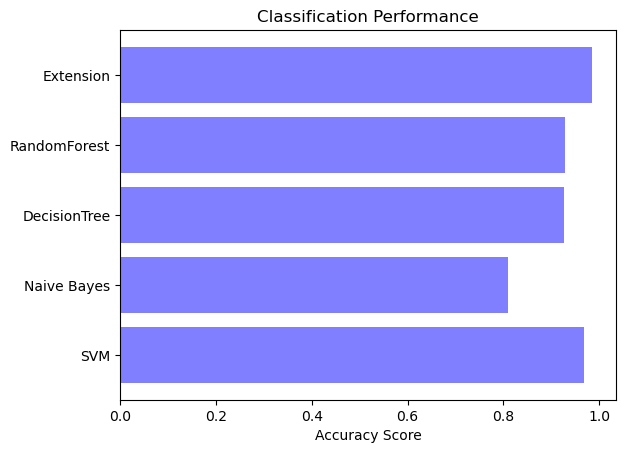

In [77]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

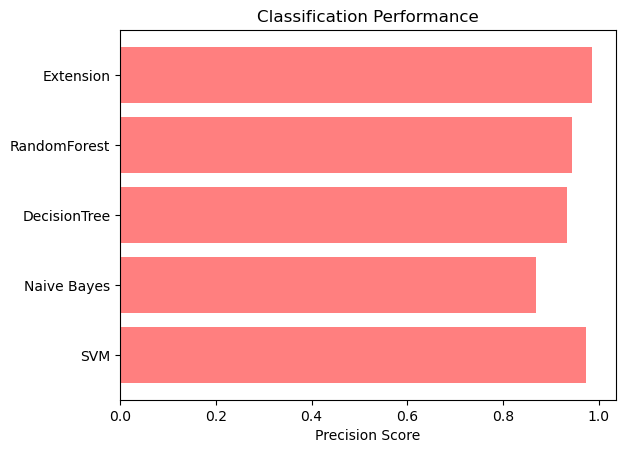

In [78]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

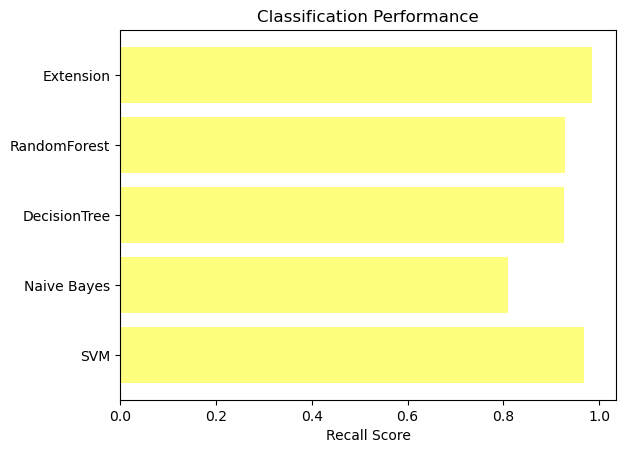

In [79]:
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

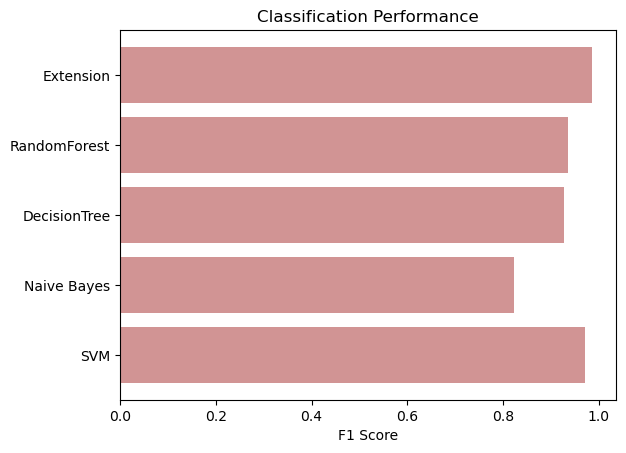

In [80]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='brown')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()

# AUC

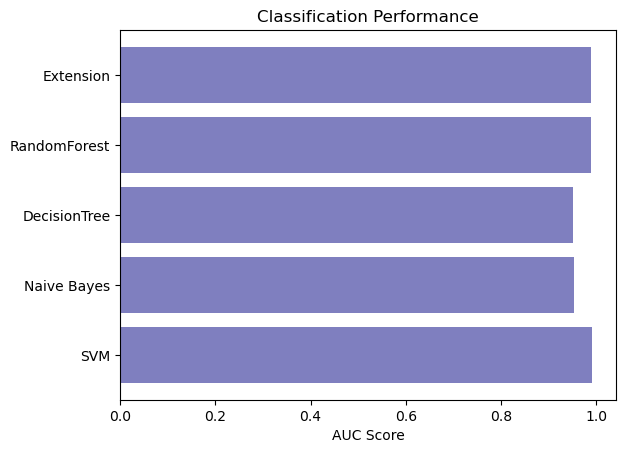

In [81]:
plt2.barh(y_pos, auc, align='center', alpha=0.5,color='navy')
plt2.yticks(y_pos, classifier)
plt2.xlabel('AUC Score')
plt2.title('Classification Performance')
plt2.show()

# FPR

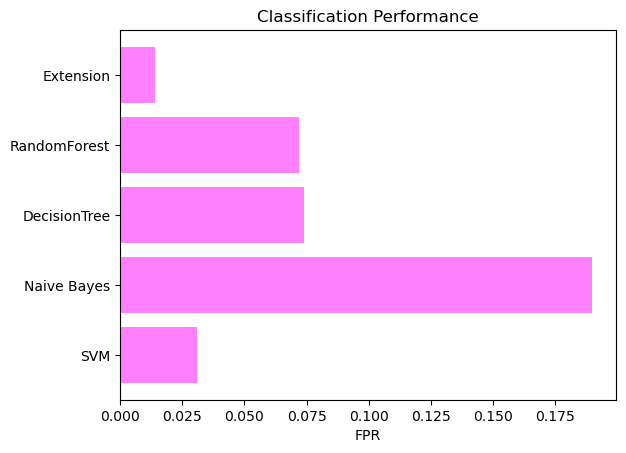

In [82]:
plt2.barh(y_pos, fpr, align='center', alpha=0.5,color='magenta')
plt2.yticks(y_pos, classifier)
plt2.xlabel('FPR')
plt2.title('Classification Performance')
plt2.show()

# FNR

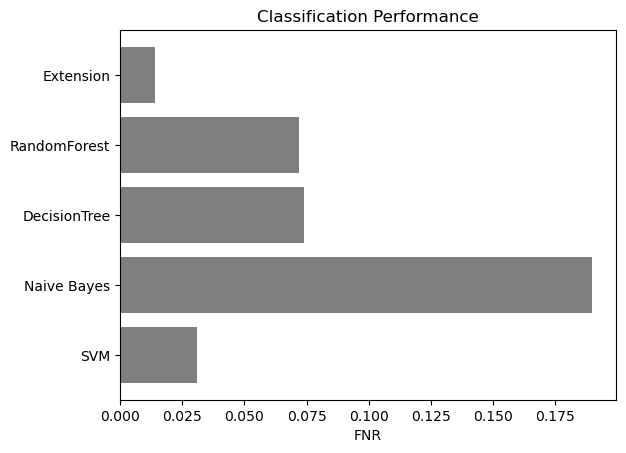

In [83]:
plt2.barh(y_pos, fnr, align='center', alpha=0.5,color='black')
plt2.yticks(y_pos, classifier)
plt2.xlabel('FNR')
plt2.title('Classification Performance')
plt2.show()

# CFS

In [17]:
X = data.drop(["attack"],axis =1)
y = data["attack"]

In [18]:
corr_matrix = data.corr()
corr_with_target = corr_matrix['attack']

In [19]:
k = 15
top_k = corr_with_target.abs().sort_values(ascending=False)[:k].index
selected_features = data[top_k]

In [20]:
selected_features.columns

Index(['attack', 'dst_host_srv_count', 'same_srv_rate', 'logged_in',
       'dst_host_same_srv_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'serror_rate', 'srv_serror_rate', 'flag',
       'count', 'dst_host_count', 'protocol_type', 'service',
       'dst_host_rerror_rate'],
      dtype='object')

In [14]:
X = data[['dst_host_srv_count', 'same_srv_rate', 'logged_in',
       'dst_host_same_srv_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'srv_serror_rate', 'serror_rate', 'flag',
       'count', 'dst_host_count', 'protocol_type', 'service',
       'dst_host_rerror_rate']]
y = data["attack"]

In [18]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []
auc = []
fpr = []
fnr = []

#function to call for storing the results
def storeResults(model, a,b,c,d,e,f,g):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))
    auc.append(round(e, 3))
    fpr.append(round(f, 3))
    fnr.append(round(g, 3))

# SVM

In [22]:
# Create the RandomizedSearchCV object
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
from sklearn import svm
svc = svm.SVC()
param_dist = {
    'C': uniform(0.1, 10),  # Uniform distribution between 0.1 and 10
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'] + list(np.logspace(-3, 3, 50))
}
randomized_search = RandomizedSearchCV(estimator=svc, param_distributions=param_dist, n_iter=20, cv=5)

randomized_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=SVC(), n_iter=20,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001B5F05A2770>,
                                        'gamma': ['scale', 'auto', 0.001,
                                                  0.0013257113655901094,
                                                  0.0017575106248547913,
                                                  0.002329951810515372,
                                                  0.0030888435964774815,
                                                  0.004094915062380427,
                                                  0.005428675439323859,
                                                  0.0071968567300115215,
                                                  0.009540954...
                                                  0.022229964825261943,
                                                  0.029470517025518096,
                        

In [25]:
# Get the best hyperparameters and model
best_params_rand = randomized_search.best_params_
best_model_rand = randomized_search.best_estimator_

# Evaluate the best model
y_pred_best_rand = best_model_rand.predict(X_test_pca)
accuracy_best_rand = accuracy_score(y_test, y_pred_best_rand)
print(f"Best SVM Accuracy: {accuracy_best_rand:.2f}")
print(f"Best Hyperparameters: {best_params_rand}")

Best SVM Accuracy: 0.97
Best Hyperparameters: {'C': 1.5248433053083243, 'gamma': 0.28117686979742307, 'kernel': 'rbf'}


In [27]:
svc = svm.SVC(C=1.5248433053083243, gamma=0.28117686979742307, kernel='rbf',probability=True)
svc.fit(X_train, y_train)

y_pred    = svc.predict(X_test)

svc_acc = accuracy_score(y_pred, y_test)
svc_prec = precision_score(y_pred, y_test,average='weighted')
svc_rec = recall_score(y_pred, y_test,average='weighted')
svc_f1 = f1_score(y_pred, y_test,average='weighted')
svc_auc = roc_auc_score(y_test, svc.predict_proba(X_test), multi_class='ovr')
tpr = recall_score(y_pred, y_test,average='weighted')
tnr = recall_score(y_pred, y_test,average='weighted', pos_label = 0) 
svc_fpr = 1 - tnr
svc_fnr = 1 - tpr

In [28]:
storeResults('SVM',svc_acc,svc_prec,svc_rec,svc_f1,svc_auc,svc_fpr,svc_fnr)

# Naive Bayes

In [29]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

params_NB = {'var_smoothing': np.logspace(0,-9, num=100)}
# Create the RandomizedSearchCV object
randomized_search = RandomizedSearchCV(estimator=nb, param_distributions=params_NB, n_iter=20, cv=5)

randomized_search.fit(X_train_pca, y_train)

RandomizedSearchCV(cv=5, estimator=GaussianNB(), n_iter=20,
                   param_distributions={'var_smoothing': array([1.00000000e+00, 8.11130831e-01, 6.57933225e-01, 5.33669923e-01,
       4.32876128e-01, 3.51119173e-01, 2.84803587e-01, 2.31012970e-01,
       1.87381742e-01, 1.51991108e-01, 1.23284674e-01, 1.00000000e-01,
       8.11130831e-02, 6.57933225e-02, 5.33669923e-02, 4.32876128e-02,
       3.5111917...
       1.23284674e-07, 1.00000000e-07, 8.11130831e-08, 6.57933225e-08,
       5.33669923e-08, 4.32876128e-08, 3.51119173e-08, 2.84803587e-08,
       2.31012970e-08, 1.87381742e-08, 1.51991108e-08, 1.23284674e-08,
       1.00000000e-08, 8.11130831e-09, 6.57933225e-09, 5.33669923e-09,
       4.32876128e-09, 3.51119173e-09, 2.84803587e-09, 2.31012970e-09,
       1.87381742e-09, 1.51991108e-09, 1.23284674e-09, 1.00000000e-09])})

In [30]:
# Get the best hyperparameters and model
best_params_rand = randomized_search.best_params_
best_model_rand = randomized_search.best_estimator_

# Evaluate the best model
y_pred_best_rand = best_model_rand.predict(X_test_pca)
accuracy_best_rand = accuracy_score(y_test, y_pred_best_rand)
print(f"Best NB Accuracy: {accuracy_best_rand:.2f}")
print(f"Best Hyperparameters: {best_params_rand}")

Best NB Accuracy: 0.75
Best Hyperparameters: {'var_smoothing': 5.336699231206313e-07}


In [32]:
nb = GaussianNB(var_smoothing = 5.336699231206313e-07)
nb.fit(X_train, y_train)

y_pred    = nb.predict(X_test)

nb_acc = accuracy_score(y_pred, y_test)
nb_prec = precision_score(y_pred, y_test,average='weighted')
nb_rec = recall_score(y_pred, y_test,average='weighted')
nb_f1 = f1_score(y_pred, y_test,average='weighted')
nb_auc = roc_auc_score(y_test, nb.predict_proba(X_test), multi_class='ovr')
tpr = recall_score(y_pred, y_test,average='weighted')
tnr = recall_score(y_pred, y_test,average='weighted', pos_label = 0) 
nb_fpr = 1 - tnr
nb_fnr = 1 - tpr

In [33]:
storeResults('Naive Bayes',nb_acc,nb_prec,nb_rec,nb_f1,nb_auc,nb_fpr,nb_fnr)

# DecisionTree

In [35]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5,min_samples_split=2)
dt.fit(X_train, y_train)

y_pred    = dt.predict(X_test)

dt_acc = accuracy_score(y_pred, y_test)
dt_prec = precision_score(y_pred, y_test,average='weighted')
dt_rec = recall_score(y_pred, y_test,average='weighted')
dt_f1 = f1_score(y_pred, y_test,average='weighted')
dt_auc = roc_auc_score(y_test, dt.predict_proba(X_test), multi_class='ovr')
tpr = recall_score(y_pred, y_test,average='weighted')
tnr = recall_score(y_pred, y_test,average='weighted', pos_label = 0) 
dt_fpr = 1 - tnr
dt_fnr = 1 - tpr

In [36]:
storeResults('DecisionTree',dt_acc,dt_prec,dt_rec,dt_f1,dt_auc,dt_fpr,dt_fnr)

# Random FOrest

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(max_depth=4,n_estimators=200,min_samples_split=2)
rf.fit(X_train, y_train)

y_pred    = rf.predict(X_test)

rf_acc = accuracy_score(y_pred, y_test)
rf_prec = precision_score(y_pred, y_test,average='weighted')
rf_rec = recall_score(y_pred, y_test,average='weighted')
rf_f1 = f1_score(y_pred, y_test,average='weighted')
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test), multi_class='ovr')
tpr = recall_score(y_pred, y_test,average='weighted')
tnr = recall_score(y_pred, y_test,average='weighted', pos_label = 0) 
rf_fpr = 1 - tnr
rf_fnr = 1 - tpr

In [38]:
storeResults('RandomForest',rf_acc,rf_prec,rf_rec,rf_f1,rf_auc,rf_fpr,rf_fnr)

# Voting Classifier

In [20]:
from sklearn.ensemble import VotingClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

brf = BaggingClassifier(RandomForestClassifier())
bdt = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), algorithm="SAMME", n_estimators=200
)

model = VotingClassifier(estimators= [('BagRF', brf),('BoostDT', bdt)], voting='soft')

model.fit(X_train, y_train)

y_pred    = model.predict(X_test)

ext_acc = accuracy_score(y_pred, y_test)
ext_prec = precision_score(y_pred, y_test,average='weighted')
ext_rec = recall_score(y_pred, y_test,average='weighted')
ext_f1 = f1_score(y_pred, y_test,average='weighted')
ext_auc = roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr')
tpr = recall_score(y_pred, y_test,average='weighted')
tnr = recall_score(y_pred, y_test,average='weighted', pos_label = 0) 
ext_fpr = 1 - tnr
ext_fnr = 1 - tpr

In [42]:
storeResults('Extension',ext_acc,ext_prec,ext_rec,ext_f1,ext_auc,ext_fpr,ext_fnr)

# Comparison

In [43]:
#creating dataframe
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                       'Precision': precision,
                       'Recall'   : recall, 
                       'F1_score' : f1score,
                       'AUC'  : auc,
                       'FPR' : fpr,
                       'FNR' : fnr
                      }) 

In [44]:
result

,ML Model,Accuracy,Precision,Recall,F1_score,AUC,FPR,FNR
0,SVM,0.783,0.856,0.783,0.779,0.979,0.217,0.217
1,Naive Bayes,0.693,0.700,0.693,0.693,0.915,0.307,0.307
2,DecisionTree,0.858,0.871,0.858,0.859,0.963,0.142,0.142
3,RandomForest,0.856,0.889,0.856,0.863,0.982,0.144,0.144
4,Extension,0.988,0.988,0.988,0.988,0.982,0.012,0.012


# Modelling

In [22]:
import joblib
filename = 'model_clf_nsl.sav'
joblib.dump(model, filename)

['model_clf_nsl.sav']

# Graph

In [47]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

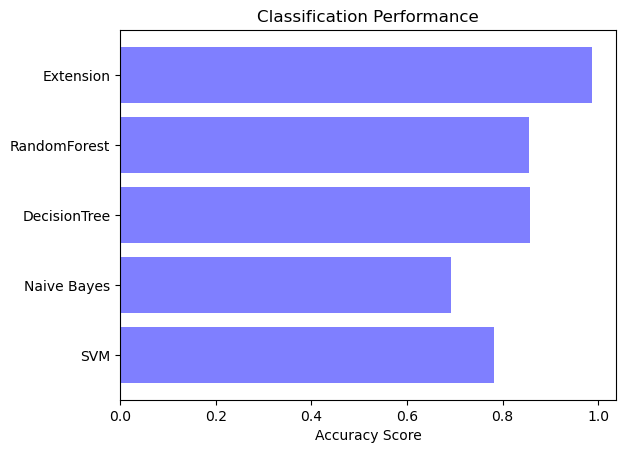

In [48]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

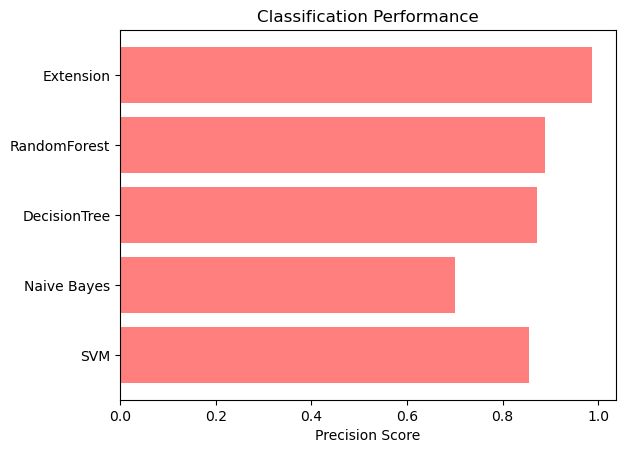

In [49]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

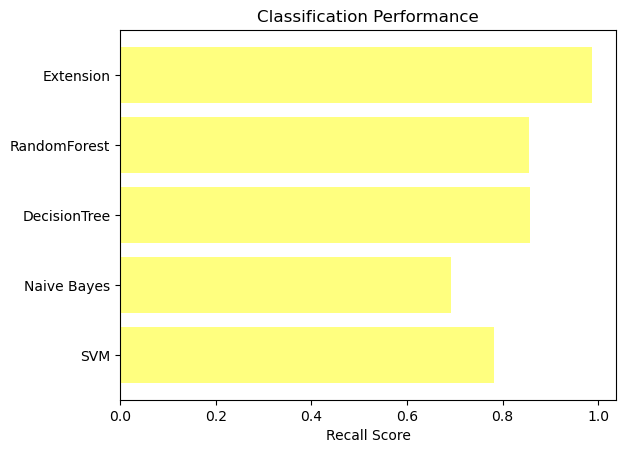

In [51]:
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

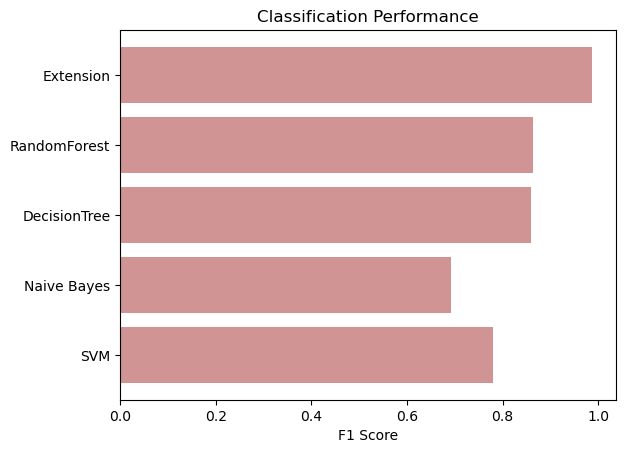

In [52]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='brown')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()

# AUC

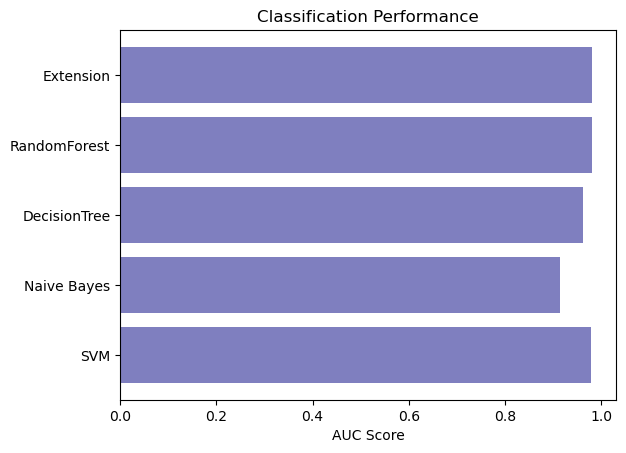

In [53]:
plt2.barh(y_pos, auc, align='center', alpha=0.5,color='navy')
plt2.yticks(y_pos, classifier)
plt2.xlabel('AUC Score')
plt2.title('Classification Performance')
plt2.show()

# FPR

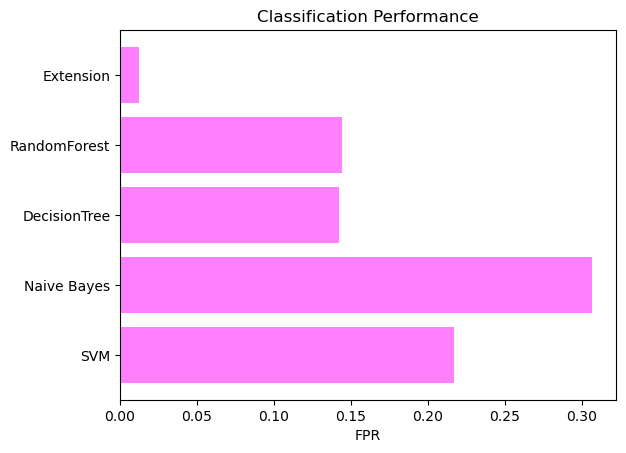

In [54]:
plt2.barh(y_pos, fpr, align='center', alpha=0.5,color='magenta')
plt2.yticks(y_pos, classifier)
plt2.xlabel('FPR')
plt2.title('Classification Performance')
plt2.show()

# FNR

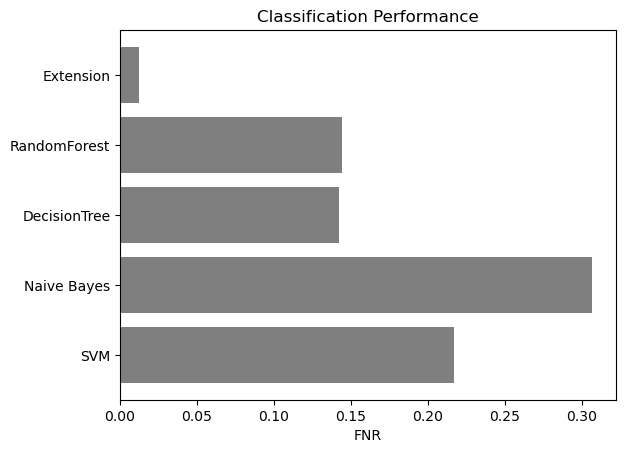

In [55]:
plt2.barh(y_pos, fnr, align='center', alpha=0.5,color='black')
plt2.yticks(y_pos, classifier)
plt2.xlabel('FNR')
plt2.title('Classification Performance')
plt2.show()